Python import statements 

In [10]:
import PIL.Image as image 
import numpy as np 
import matplotlib.pyplot as plt 

Load a image and show the orginal image

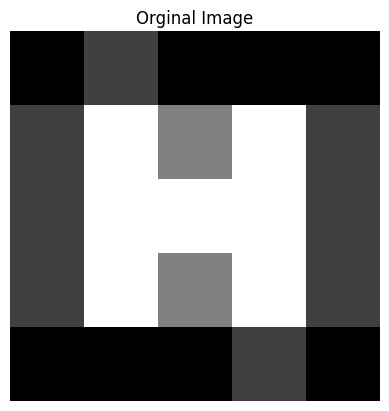

In [12]:
img_array = np.array([
    [1, 2, 1, 1, 1],
    [2, 5, 3, 5, 2],
    [2, 5, 5, 5, 2],
    [2, 5, 3, 5, 2],
    [1, 1, 1, 2, 1],
])

plt.imshow(img_array, cmap="gray")
plt.title("Orginal Image")
plt.axis("off")
plt.show()

a) Compute frequency of each intensity level 

Before histogram:  [0 0 0 0 0 0 0 0]
pixels:  [1 2 1 1 1 2 5 3 5 2 2 5 5 5 2 2 5 3 5 2 1 1 1 2 1]
After histogram:  [0 8 8 2 0 7 0 0]


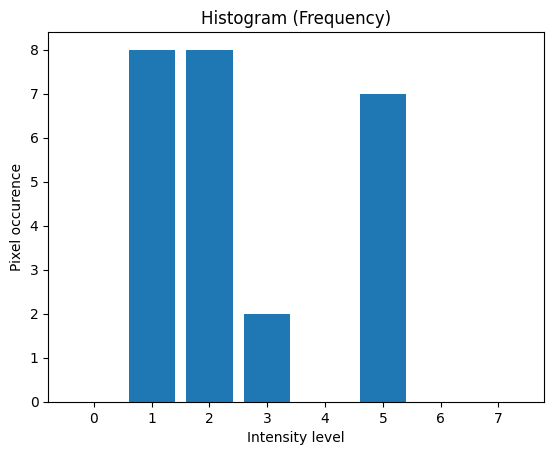

In [15]:
hist = np.zeros(8, dtype=int)
print("Before histogram: ", hist)

pixels = img_array.flatten()
print("pixels: ", pixels)

for i in pixels:
    hist[i] += 1

print("After histogram: ", hist)

plt.bar(range(8), hist)
plt.title("Histogram (Frequency)")
plt.xlabel("Intensity level")
plt.ylabel("Pixel occurence")
plt.show()

b)	Calculate probability density function (PDF) 

In [16]:
total_pixels = img_array.size
print("Total pixels: ", total_pixels)

pdf = np.zeros(8, dtype=float)
print("Before pdf: ", pdf)

for i in range(8):
    pdf[i] = hist[i] / total_pixels

print("After pdf: ", pdf)

Total pixels:  25
Before pdf:  [0. 0. 0. 0. 0. 0. 0. 0.]
After pdf:  [0.   0.32 0.32 0.08 0.   0.28 0.   0.  ]


c)	Compute cumulative distribution function (CDF) 

In [20]:
cdf = np.zeros(8, dtype=float)
print("Before cdf: ", cdf)

cdf[0] = pdf[0]

for i in range(1, 8):
    cdf[i] = cdf[i-1] + pdf[i]

print("After cdf: ", cdf)

Before cdf:  [0. 0. 0. 0. 0. 0. 0. 0.]
After cdf:  [0.   0.32 0.64 0.72 0.72 1.   1.   1.  ]


d)	Map old pixel values to new values

New level:  [0. 2. 4. 5. 5. 7. 7. 7.]
Equalized img:  [[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Height * width:  5 5
after equalized_img:  [[2 4 2 2 2]
 [4 7 5 7 4]
 [4 7 7 7 4]
 [4 7 5 7 4]
 [2 2 2 4 2]]


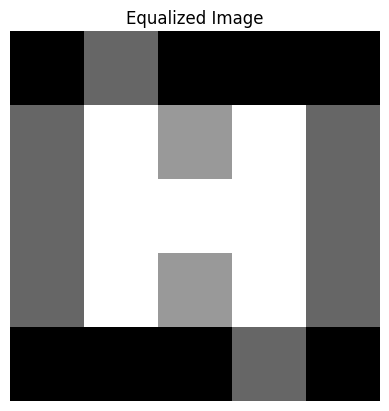

In [19]:
new_level = np.round(7 * cdf) 
print("New level: ", new_level)

equalized_img = np.zeros_like(img_array)
print("Equalized img: ", equalized_img)

H, W = img_array.shape
print("Height * width: ", H, W)

for i in range(H):
    for j in range(W):
        equalized_img[i, j] = new_level[img_array[i, j]]

print("after equalized_img: ", equalized_img)

plt.imshow(equalized_img, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')
plt.show()

Histogram after equalization

Before hist:  [0 0 0 0 0 0 0 0]
Pixels:  [2 4 2 2 2 4 7 5 7 4 4 7 7 7 4 4 7 5 7 4 2 2 2 4 2]


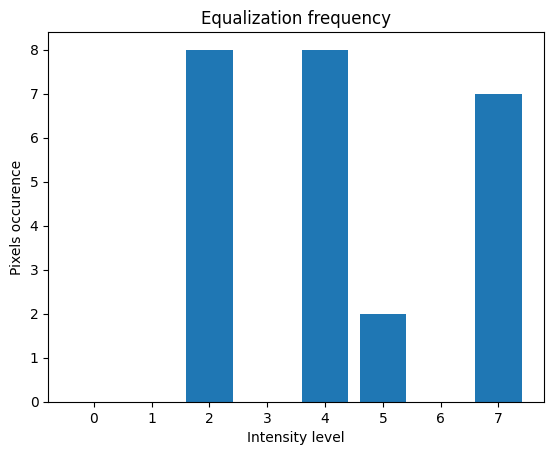

In [23]:
hist = np.zeros(8, dtype=int)
print("Before hist: ", hist)

pixels = equalized_img.flatten()
print("Pixels: ", pixels)

for i in pixels:
    hist[i] += 1

plt.bar(range(8), hist)
plt.title("Equalization frequency")
plt.xlabel("Intensity level")
plt.ylabel("Pixels occurence")

plt.show()